# CSE 36301 Assignment1
20201118 박정훈

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import pandas as pd
from typing import Tuple, Optional
from sklearn.datasets import make_regression, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
warnings.filterwarnings('ignore')

In [2]:
# ============================================================================
# PART 1: Normal Equations
# ============================================================================

def add_intercept(X: np.ndarray) -> np.ndarray:
    """
    Add intercept term (bias) to the feature matrix.

    Args:
        X: Feature matrix of shape (n_samples, n_features)

    Returns:
        Feature matrix with intercept column of shape (n_samples, n_features + 1)
    """
    # TODO: Add a column of ones at the beginning of X
    # Hint: Use np.ones and np.column_stack or np.hstack
    beg_column = np.ones((X.shape[0], 1))
    return np.column_stack((beg_column, X))
    pass

def normal_equation_solution(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Compute the closed-form solution for linear regression using normal equations.

    The solution is: theta = (X^T * X)^(-1) * X^T * y

    Args:
        X: Feature matrix of shape (n_samples, n_features) (should include intercept)
        y: Target vector of shape (n_samples,)

    Returns:
        Optimal parameters theta of shape (n_features,)
    """
    # TODO: Implement the normal equation solution
    # Steps:
    # 1. Compute X^T (transpose of X)
    # 2. Compute X^T * X
    # 3. Compute the inverse of (X^T * X)
    # 4. Compute X^T * y
    # 5. Multiply (X^T * X)^(-1) with X^T * y
    XT = X.T
    XTX = XT @ X
    XTX_inv = np.linalg.inv(XTX)
    XTy = XT @ y
    return XTX_inv @ XTy
    pass

def compute_mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Compute Mean Squared Error between true and predicted values.

    Args:
        y_true: True target values
        y_pred: Predicted values

    Returns:
        Mean squared error
    """
    # TODO: Implement MSE calculation
    errors = y_pred - y_true
    mse = np.mean(errors ** 2)
    return mse
    pass

def predict(X: np.ndarray, theta: np.ndarray) -> np.ndarray:
    """
    Make predictions using linear regression model.

    Args:
        X: Feature matrix (should include intercept if theta includes bias term)
        theta: Model parameters

    Returns:
        Predicted values
    """
    # TODO: Implement prediction
    return X @ theta
    pass

In [3]:
def test_with_diabetes_dataset():
    """Test the implementation with the diabetes dataset from sklearn."""
    print("=" * 60)
    print("TESTING WITH DIABETES DATASET")
    print("=" * 60)

    # Load the diabetes dataset
    diabetes = load_diabetes()
    X, y = diabetes.data, diabetes.target

    print(f"Dataset shape: {X.shape}")
    print(f"Feature names: {diabetes.feature_names}")
    print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Standardize features (recommended for normal equations)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Add intercept to your implementation
    X_train_with_intercept = add_intercept(X_train_scaled)
    X_test_with_intercept = add_intercept(X_test_scaled)

    # Your implementation
    theta = normal_equation_solution(X_train_with_intercept, y_train)
    y_pred_train = predict(X_train_with_intercept, theta)
    y_pred_test = predict(X_test_with_intercept, theta)

    train_mse = compute_mse(y_train, y_pred_train)
    test_mse = compute_mse(y_test, y_pred_test)

    print(f"\nYour Implementation:")
    print(f"Train MSE: {train_mse:.2f}")
    print(f"Test MSE: {test_mse:.2f}")
    print(f"Intercept (theta[0]): {theta[0]:.2f}")
    print(f"Coefficients: {theta[1:].round(2)}")

    # Compare with sklearn
    sklearn_model = LinearRegression()
    sklearn_model.fit(X_train_scaled, y_train)
    sklearn_pred_train = sklearn_model.predict(X_train_scaled)
    sklearn_pred_test = sklearn_model.predict(X_test_scaled)

    sklearn_train_mse = compute_mse(y_train, sklearn_pred_train)
    sklearn_test_mse = compute_mse(y_test, sklearn_pred_test)

    print(f"\nSklearn Implementation:")
    print(f"Train MSE: {sklearn_train_mse:.2f}")
    print(f"Test MSE: {sklearn_test_mse:.2f}")
    print(f"Intercept: {sklearn_model.intercept_:.2f}")
    print(f"Coefficients: {sklearn_model.coef_.round(2)}")

    # Check if results are close
    theta_diff = abs(theta[0] - sklearn_model.intercept_)
    coef_diff = np.mean(abs(theta[1:] - sklearn_model.coef_))

    print(f"\nDifferences:")
    print(f"Intercept difference: {theta_diff:.6f}")
    print(f"Mean coefficient difference: {coef_diff:.6f}")
    print(f"Results match: {theta_diff < 1e-10 and coef_diff < 1e-10}")

    return theta, sklearn_model
test_with_diabetes_dataset()

TESTING WITH DIABETES DATASET
Dataset shape: (442, 10)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target range: [25.00, 346.00]

Your Implementation:
Train MSE: 2868.55
Test MSE: 2900.19
Intercept (theta[0]): 153.74
Coefficients: [  1.75 -11.51  25.61  16.83 -44.45  24.64   7.68  13.14  35.16   2.35]

Sklearn Implementation:
Train MSE: 2868.55
Test MSE: 2900.19
Intercept: 153.74
Coefficients: [  1.75 -11.51  25.61  16.83 -44.45  24.64   7.68  13.14  35.16   2.35]

Differences:
Intercept difference: 0.000000
Mean coefficient difference: 0.000000
Results match: True


(array([153.73654391,   1.75375799, -11.51180908,  25.60712144,
         16.82887167, -44.44885564,  24.64095356,   7.67697768,
         13.1387839 ,  35.16119521,   2.35136365]),
 LinearRegression())

In [4]:
# ============================================================================
# PART 2: GRADIENT DESCENT IMPLEMENTATION
# ============================================================================

def compute_cost_and_gradient(X: np.ndarray, y: np.ndarray, theta: np.ndarray) -> Tuple[float, np.ndarray]:
    """
    Compute the cost (MSE) and gradient for linear regression.

    Args:
        X: Feature matrix of shape (n_samples, n_features)
        y: Target vector of shape (n_samples,)
        theta: Current parameters of shape (n_features,)

    Returns:
        Tuple of (cost, gradient)
        - cost: Mean squared error
        - gradient: Gradient vector of shape (n_features,)
    """
    m = X.shape[0]  # number of training examples

    # TODO: Implement cost and gradient computation
    # Cost: J(theta) = (1/2m) * sum((X*theta - y)^2)
    # Gradient: dJ/dtheta = (1/m) * X^T * (X*theta - y)
    #
    # Steps:
    # 1. Compute predictions: h = X * theta
    # 2. Compute errors: errors = h - y
    # 3. Compute cost: J = (1/2m) * sum(errors^2)
    # 4. Compute gradient: grad = (1/m) * X^T * errors
    h = X @ theta
    errors = h - y
    J = (1 / (2 * m)) * np.sum(errors ** 2)
    grad = (1 / m) * X.T @ errors
    return J, grad
    pass

def gradient_descent(X: np.ndarray, y: np.ndarray, theta_init: np.ndarray,
                    learning_rate: float, num_iterations: int,
                    tolerance: float = 1e-6) -> Tuple[np.ndarray, np.ndarray]:
    """
    Perform gradient descent to optimize linear regression parameters.

    Args:
        X: Feature matrix
        y: Target vector
        theta_init: Initial parameters
        learning_rate: Learning rate (alpha)
        num_iterations: Maximum number of iterations
        tolerance: Convergence tolerance for cost change

    Returns:
        Tuple of (final_theta, cost_history)
        - final_theta: Optimized parameters
        - cost_history: Cost at each iteration
    """
    theta = theta_init.copy()
    cost_history = []

    for i in range(num_iterations):
        # TODO: Implement gradient descent update
        # 1. Compute current cost and gradient
        # 2. Update theta: theta = theta - learning_rate * gradient
        # 3. Store cost in history
        # 4. Check for convergence (optional)

        cost, gradient = compute_cost_and_gradient(X, y, theta)

        # TODO: Update theta using gradient descent rule
        theta -= learning_rate * gradient
        cost_history.append(cost)

        # Check for convergence
        if i > 0 and abs(cost_history[-2] - cost_history[-1]) < tolerance:
            print(f"Converged after {i+1} iterations")
            break

    return theta, np.array(cost_history)

GRADIENT DESCENT CONVERGENCE ANALYSIS (FIXED)
Dataset shape: (442, 11)
Ground truth cost: 1429.848174
Ground truth params: [152.1335  -0.4761 -11.4069  24.7265  15.4294 -37.68    22.6762   4.8061
   8.422   35.7344   3.2167]

--------------------------------------------------
Testing Learning Rate: 0.5
--------------------------------------------------
  Iterations completed: 5000
  Final cost: 16144466146090366121492392384170461014720888442340769792.000000
  True cost:  1429.848174
  Cost error: 16144466146090366121492392384170461014720888442340769792.000000
  Cost ratio: 11291035259540343285397700767293984000783564362743808.0000
  Parameter error: 2866897824116855098117718016.000000
  📊 Status: ❌ DIVERGED - Cost exploded

--------------------------------------------------
Testing Learning Rate: 0.48
--------------------------------------------------
Converged after 3027 iterations
  Iterations completed: 3027
  Final cost: 1429.848174
  True cost:  1429.848174
  Cost error: 0.000000


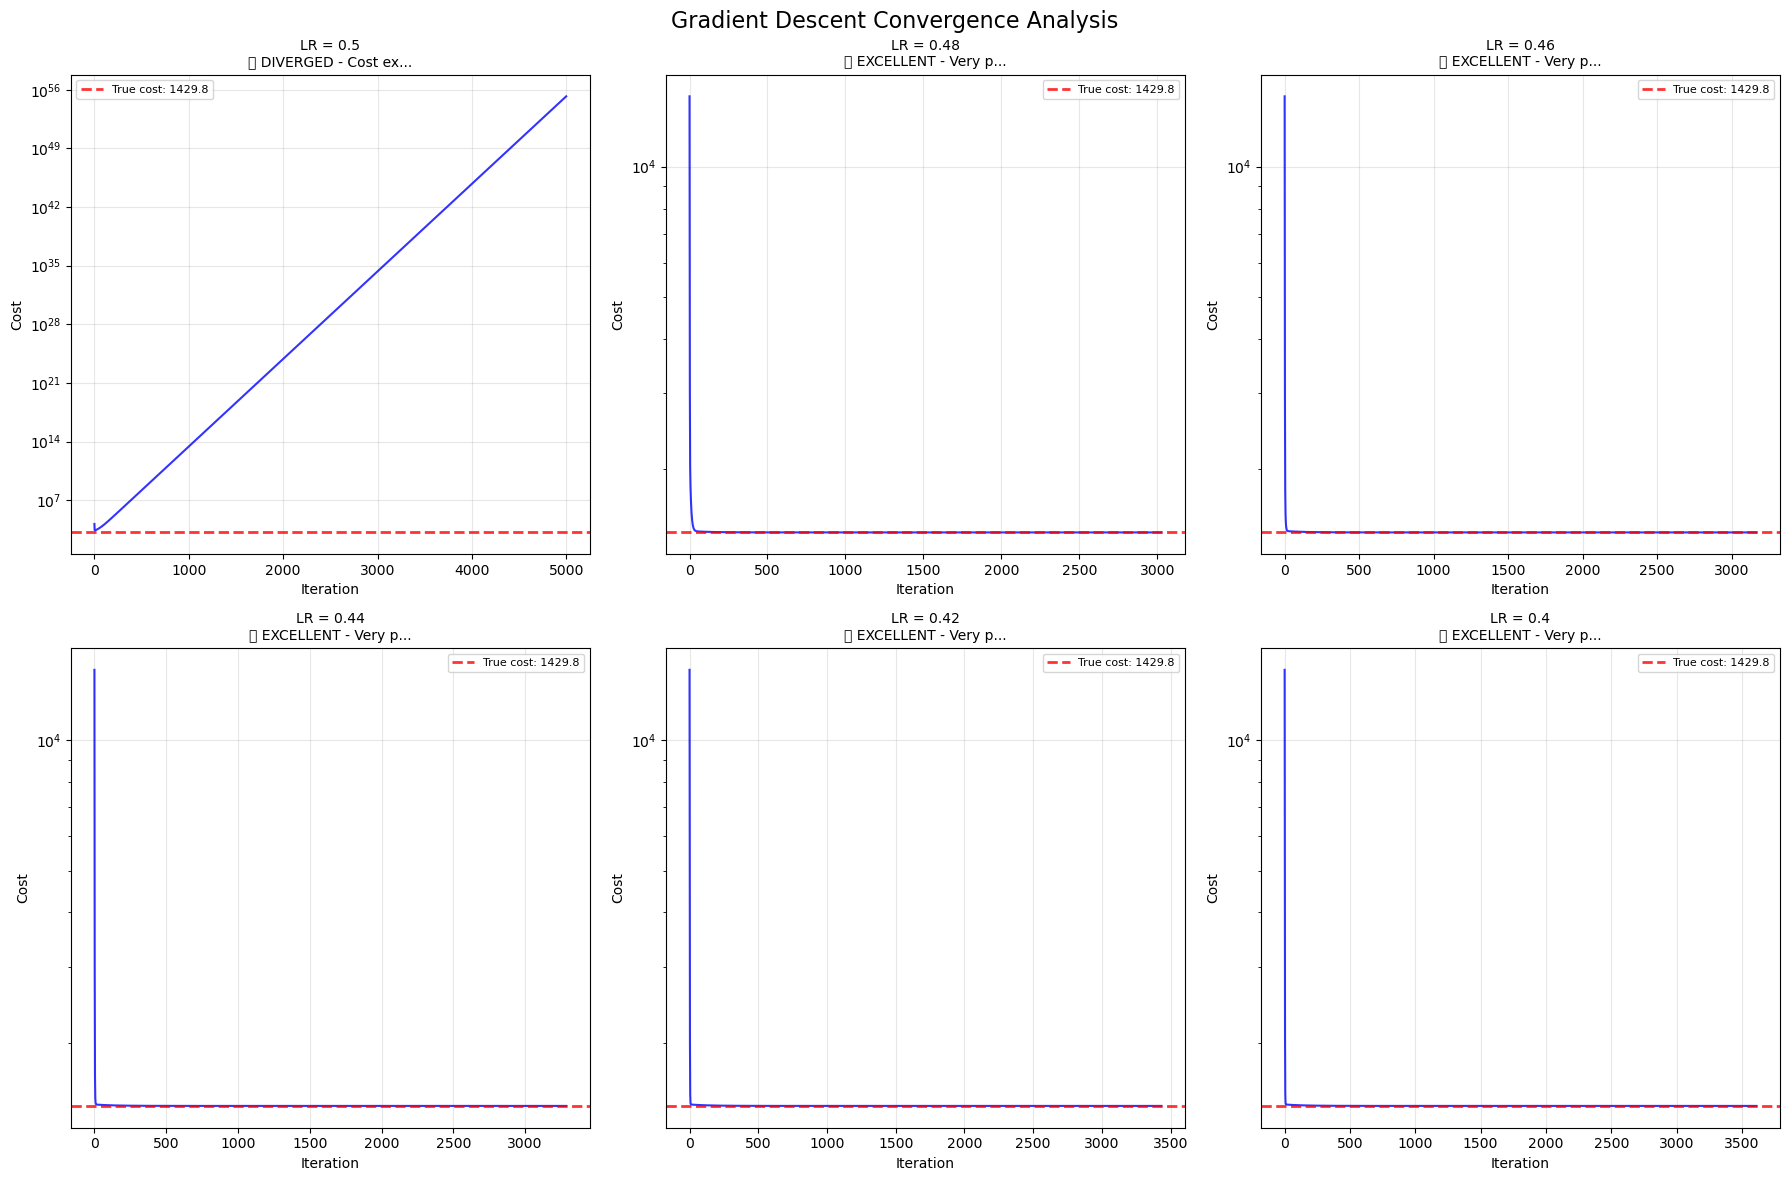


CONVERGENCE SUMMARY
❌ LR =  0.500: ❌ DIVERGED - Cost exploded
✅ LR =  0.480: ✅ EXCELLENT - Very precise
✅ LR =  0.460: ✅ EXCELLENT - Very precise
✅ LR =  0.440: ✅ EXCELLENT - Very precise
✅ LR =  0.420: ✅ EXCELLENT - Very precise
✅ LR =  0.400: ✅ EXCELLENT - Very precise

🎯 Best Learning Rate: 0.46
   Cost Error: 0.00000000
   Param Error: 0.000191


In [5]:
def test_gradient_descent_convergence():
    """Test gradient descent convergence with different learning rates - FIXED VERSION."""
    print("=" * 70)
    print("GRADIENT DESCENT CONVERGENCE ANALYSIS (FIXED)")
    print("=" * 70)

    # Load and prepare diabetes dataset
    diabetes = load_diabetes()
    X, y = diabetes.data, diabetes.target

    # Standardize features and add intercept
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_with_intercept = add_intercept(X_scaled)

    # Get ground truth from normal equation
    theta_true = normal_equation_solution(X_with_intercept, y)
    true_cost, _ = compute_cost_and_gradient(X_with_intercept, y, theta_true)

    print(f"Dataset shape: {X_with_intercept.shape}")
    print(f"Ground truth cost: {true_cost:.6f}")
    print(f"Ground truth params: {theta_true.round(4)}")

    # Test different learning rates
    # learning_rates = [1.0, 0.5, 0.1, 0.05, 0.01, 0.001]
    learning_rates = [0.50, 0.48, 0.46, 0.44, 0.42, 0.40]
    results = {}

    plt.figure(figsize=(18, 12))

    for i, lr in enumerate(learning_rates):
        print(f"\n{'-'*50}")
        print(f"Testing Learning Rate: {lr}")
        print(f"{'-'*50}")

        # Initialize parameters to zero
        theta_init = np.zeros(X_with_intercept.shape[1])

        try:
            # Run gradient descent
            theta_final, cost_history = gradient_descent(
                X_with_intercept, y, theta_init,
                learning_rate=lr, num_iterations=5000, tolerance=1e-12
            )

            # Calculate errors
            param_error = np.linalg.norm(theta_final - theta_true)
            final_cost = cost_history[-1]
            cost_error = abs(final_cost - true_cost)
            cost_ratio = final_cost / true_cost

            print(f"  Iterations completed: {len(cost_history)}")
            print(f"  Final cost: {final_cost:.6f}")
            print(f"  True cost:  {true_cost:.6f}")
            print(f"  Cost error: {cost_error:.6f}")
            print(f"  Cost ratio: {cost_ratio:.4f}")
            print(f"  Parameter error: {param_error:.6f}")

            # Detailed convergence analysis
            convergence_status = analyze_convergence(
                cost_history, cost_error, param_error, final_cost, true_cost
            )
            print(f"  📊 Status: {convergence_status}")

            # Store results
            results[lr] = {
                'theta': theta_final,
                'cost_history': cost_history,
                'final_cost': final_cost,
                'cost_error': cost_error,
                'param_error': param_error,
                'status': convergence_status,
                'converged': 'EXCELLENT' in convergence_status or 'GOOD' in convergence_status
            }

        except Exception as e:
            print(f"  ❌ FAILED: {str(e)}")
            results[lr] = {'status': f'FAILED: {str(e)}', 'converged': False}

        # Plot cost history
        if lr in results and 'cost_history' in results[lr]:
            plt.subplot(2, 3, i + 1)
            cost_history = results[lr]['cost_history']

            plt.plot(cost_history, 'b-', linewidth=1.5, alpha=0.8)
            plt.axhline(y=true_cost, color='r', linestyle='--', alpha=0.8,
                       linewidth=2, label=f'True cost: {true_cost:.1f}')

            plt.title(f'LR = {lr}\n{results[lr]["status"][:20]}...', fontsize=10)
            plt.xlabel('Iteration')
            plt.ylabel('Cost')
            plt.grid(True, alpha=0.3)
            plt.legend(fontsize=8)

            # Use log scale if cost varies a lot
            if len(cost_history) > 0:
                cost_range = max(cost_history) - min(cost_history)
                if cost_range > true_cost * 2:
                    plt.yscale('log')
        else:
            plt.subplot(2, 3, i + 1)
            plt.text(0.5, 0.5, f'FAILED\nLR = {lr}',
                    ha='center', va='center', transform=plt.gca().transAxes,
                    fontsize=12, color='red')
            plt.title(f'LR = {lr}')

    plt.suptitle('Gradient Descent Convergence Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Summary
    print(f"\n{'='*70}")
    print("CONVERGENCE SUMMARY")
    print('='*70)

    converged_lrs = []
    for lr, result in results.items():
        if result['converged']:
            converged_lrs.append(lr)
            print(f"✅ LR = {lr:6.3f}: {result['status']}")
        else:
            print(f"❌ LR = {lr:6.3f}: {result['status']}")

    if converged_lrs:
        best_lr = min(converged_lrs, key=lambda lr: results[lr]['cost_error'])
        print(f"\n🎯 Best Learning Rate: {best_lr}")
        print(f"   Cost Error: {results[best_lr]['cost_error']:.8f}")
        print(f"   Param Error: {results[best_lr]['param_error']:.6f}")
    else:
        print(f"\n❌ No learning rates achieved good convergence!")
        print(f"   Try smaller learning rates or more iterations")

def analyze_convergence(cost_history, cost_error, param_error, final_cost, true_cost):
    """Analyze convergence quality and return status string."""

    # Check for numerical issues
    if np.isnan(final_cost) or np.isinf(final_cost) or np.isnan(param_error):
        return "❌ DIVERGED - NaN/Inf detected"

    # Check for explosive divergence
    if final_cost > true_cost * 100:
        return "❌ DIVERGED - Cost exploded"

    # Check if cost is way too high
    if final_cost > true_cost * 10:
        return "❌ POOR - Cost too high"

    # Analyze cost progression
    if len(cost_history) >= 100:
        recent_change = abs(cost_history[-1] - cost_history[-50])
        early_change = abs(cost_history[50] - cost_history[0]) if len(cost_history) > 50 else float('inf')

        # Still changing a lot
        if recent_change > cost_error:
            return "⚠️  SLOW - Still changing"

    # Quality based on final errors
    if cost_error < 1e-6 and param_error < 0.01:
        return "✅ EXCELLENT - Very precise"
    elif cost_error < 1e-4 and param_error < 0.1:
        return "✅ EXCELLENT - High precision"
    elif cost_error < 1e-2 and param_error < 1.0:
        return "✓ GOOD - Acceptable precision"
    elif cost_error < 0.1 and param_error < 5.0:
        return "✓ GOOD - Moderate precision"
    elif cost_error < 1.0:
        return "⚠️  PARTIAL - Low precision"
    else:
        return "❌ POOR - Very low precision"
test_gradient_descent_convergence()